# High-Dimensional BayesOpt

How does GP-based Bayesian optimisation scale with the number of hyperparameters?

We test on **10 · 100 · 1 000 dimensions** using two nD benchmark functions and
compare the default BayesianSearch against a Random Search baseline.

**What we expect to see:**
- At **10D**: BO still beats random — GP can model low-D structure.
- At **100D**: BO advantage shrinks — 50 observations cover a vanishingly small
  fraction of [0,1]^100.
- At **1 000D**: BO likely matches or loses to random — vanilla GP-BO is not
  designed for this regime (curse of dimensionality, acquisition maximisation
  degrades, ARD overfits).

This notebook measures **simple regret**, **wall-clock time per iteration**, and
**JIT compile overhead** as a function of dimensionality.


In [1]:
import time
import warnings
warnings.filterwarnings("ignore")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hyperoptax.bayesian import BayesianSearch
from hyperoptax.random import RandomSearch
from hyperoptax.spaces import LinearSpace

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print(f"JAX {jax.__version__} | devices: {jax.devices()}")


JAX 0.6.2 | devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]


## Benchmark Functions

Both functions generalise cleanly to arbitrary dimension D.

| Function | Formula | Global min | Domain |
|----------|---------|-----------|--------|
| **Ackley** | −20 exp(−0.2√(∑xᵢ²/D)) − exp(∑cos(2πxᵢ)/D) + e + 20 | 0 at **0** | [−5, 5]^D |
| **Rosenbrock** | ∑ᵢ [100(x_{i+1}−xᵢ²)² + (1−xᵢ)²] | 0 at **1** | [−2, 2]^D |

Ackley is multimodal with near-flat tails; Rosenbrock has a narrow curved valley.
Both become exponentially harder as D grows.


In [2]:
def ackley_nd(x):
    """x: (D,) array in [−5, 5]^D. Global min = 0 at x = 0."""
    D = x.shape[0]
    return (-20.0 * jnp.exp(-0.2 * jnp.sqrt(jnp.mean(x**2)))
            - jnp.exp(jnp.mean(jnp.cos(2 * jnp.pi * x)))
            + jnp.e + 20.0)

def rosenbrock_nd(x):
    """x: (D,) array in [−2, 2]^D. Global min = 0 at x = 1."""
    return jnp.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1.0 - x[:-1])**2)

FUNCTIONS = {
    "Ackley":     (ackley_nd,     LinearSpace(-5.0,  5.0), 0.0),
    "Rosenbrock": (rosenbrock_nd, LinearSpace(-2.0,  2.0), 0.0),
}

# Smoke-test
for name, (fn, _, true_opt) in FUNCTIONS.items():
    x_opt = jnp.zeros(6) if name == "Ackley" else jnp.ones(6)
    print(f"{name}(x*) = {float(fn(x_opt)):.6f}  (expected {true_opt})")


Ackley(x*) = 0.000000  (expected 0.0)
Rosenbrock(x*) = 0.000000  (expected 0.0)


N_BUDGET = 50
N_SEEDS  = 3     # fewer seeds — high-D JIT is slow enough already
SEED     = 42
DIMS     = [10, 100, 1000]

# Read n_parallel from the class default once
_DEFAULT_N_PARALLEL = BayesianSearch().n_parallel   # 4


def build_space(D, space_template):
    return {f"x{i}": space_template for i in range(D)}


def make_wrapper(fn, D):
    """Return a JAX-traceable (key, config) -> scalar wrapper for an nD function."""
    keys = [f"x{i}" for i in range(D)]
    def wrapper(key, config):
        x = jnp.stack([config[k] for k in keys])
        return -fn(x)   # maximise the negated function (global max = 0)
    return wrapper


def run_bo(space, wrapper, true_opt, n_budget=N_BUDGET, n_seeds=N_SEEDS,
           n_parallel=_DEFAULT_N_PARALLEL, **bo_kwargs):
    """
    Run BayesianSearch; return (regret, eval_x, compile_sec, run_sec).
    """
    n_iter = n_budget // n_parallel
    state0, opt = BayesianSearch.init(
        space, n_max=n_budget, n_parallel=n_parallel, **bo_kwargs
    )
    keys = jax.random.split(jax.random.PRNGKey(SEED), n_seeds)

    def _run(keys):
        def one(key):
            _, (_, res) = opt.optimize_scan(state0, key, wrapper, n_iter)
            return res          # (n_iter, n_parallel)
        return jax.vmap(one)(keys)

    jit_fn = jax.jit(_run)

    # first call = compile + run
    t0 = time.perf_counter()
    jit_fn(keys).block_until_ready()
    compile_sec = time.perf_counter() - t0

    # second call = run only (compiled)
    t0 = time.perf_counter()
    raw = np.array(jit_fn(keys).block_until_ready())
    run_sec = time.perf_counter() - t0

    flat   = raw.reshape(n_seeds, -1)                      # (n_seeds, n_budget)
    rb     = np.maximum.accumulate(flat, axis=1)
    idx    = np.arange(1, n_iter + 1) * n_parallel - 1
    regret = true_opt - rb[:, idx]                         # true max of -fn = 0
    eval_x = (np.arange(n_iter) + 1) * n_parallel
    return regret, eval_x, compile_sec, run_sec


def run_random(space, wrapper, true_opt, n_budget=N_BUDGET, n_seeds=N_SEEDS):
    state0, opt = RandomSearch.init(space)
    keys = jax.random.split(jax.random.PRNGKey(SEED), n_seeds)

    def _run(keys):
        def one(key):
            _, (_, res) = opt.optimize_scan(state0, key, wrapper, n_budget)
            return res.squeeze(-1)
        return jax.vmap(one)(keys)

    jit_fn  = jax.jit(_run)
    jit_fn(keys).block_until_ready()           # compile
    t0  = time.perf_counter()
    raw = np.array(jit_fn(keys).block_until_ready())
    run_sec = time.perf_counter() - t0

    rb     = np.maximum.accumulate(raw, axis=1)
    regret = true_opt - rb
    return regret, np.arange(1, n_budget + 1), run_sec


def plot_regret(ax, label_results, title):
    colors = {"BO": "C0", "Random": "gray"}
    styles = {"BO": "-",  "Random": "--"}
    for label, (regret, eval_x) in label_results.items():
        med = np.clip(np.median(regret, axis=0), 1e-8, None)
        q25 = np.clip(np.percentile(regret, 25, axis=0), 1e-8, None)
        q75 = np.clip(np.percentile(regret, 75, axis=0), 1e-8, None)
        c   = colors.get(label, "C1")
        ax.semilogy(eval_x, med, label=label, color=c,
                    linestyle=styles.get(label, "-"), lw=2)
        ax.fill_between(eval_x, q25, q75, alpha=0.18, color=c)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Evaluations")
    ax.set_ylabel("Regret (log)")
    ax.legend(fontsize=8)


print(f"Infrastructure ready. Default n_parallel = {_DEFAULT_N_PARALLEL}")


In [3]:
N_BUDGET = 50
N_SEEDS  = 3     # fewer seeds — high-D JIT is slow enough already
SEED     = 42
DIMS     = [10, 100, 1000]


def build_space(D, space_template):
    return {f"x{i}": space_template for i in range(D)}


def make_wrapper(fn, D):
    """Return a JAX-traceable (key, config) → scalar wrapper for an nD function."""
    keys = [f"x{i}" for i in range(D)]
    def wrapper(key, config):
        x = jnp.stack([config[k] for k in keys])
        return -fn(x)   # maximise → negate
    return wrapper


def run_bo(space, wrapper, true_opt, n_budget=N_BUDGET, n_seeds=N_SEEDS,
           n_parallel=None, **bo_kwargs):
    """
    Run BayesianSearch; return (regret, eval_x, compile_sec, run_sec).
    n_parallel defaults to the class default (4).
    """
    n_par = n_parallel if n_parallel is not None else BayesianSearch().__class__().__class__
    # resolve actual n_parallel from a temporary instance
    _tmp = BayesianSearch()
    n_par = _tmp.n_parallel if n_parallel is None else n_parallel

    n_iter = n_budget // n_par
    state0, opt = BayesianSearch.init(
        space, n_max=n_budget, n_parallel=n_par, **bo_kwargs
    )
    keys = jax.random.split(jax.random.PRNGKey(SEED), n_seeds)

    def _run(keys):
        def one(key):
            _, (_, res) = opt.optimize_scan(state0, key, wrapper, n_iter)
            return res          # (n_iter, n_par)
        return jax.vmap(one)(keys)

    # compile
    t0 = time.perf_counter()
    jit_fn = jax.jit(_run)
    raw = jit_fn(keys).block_until_ready()
    compile_sec = time.perf_counter() - t0

    # run (second call — compiled)
    t0 = time.perf_counter()
    raw = np.array(jit_fn(keys).block_until_ready())
    run_sec = time.perf_counter() - t0

    flat = raw.reshape(n_seeds, -1)
    rb   = np.maximum.accumulate(flat, axis=1)
    idx  = np.arange(1, n_iter + 1) * n_par - 1
    regret = (-true_opt) - rb[:, idx]   # true_opt = 0 for both fns so just -rb
    regret = true_opt - rb[:, idx]       # true max of -fn = -0 = 0
    eval_x = (np.arange(n_iter) + 1) * n_par
    return regret, eval_x, compile_sec, run_sec


def run_random(space, wrapper, true_opt, n_budget=N_BUDGET, n_seeds=N_SEEDS):
    state0, opt = RandomSearch.init(space)
    keys = jax.random.split(jax.random.PRNGKey(SEED), n_seeds)

    def _run(keys):
        def one(key):
            _, (_, res) = opt.optimize_scan(state0, key, wrapper, n_budget)
            return res.squeeze(-1)
        return jax.vmap(one)(keys)

    t0  = time.perf_counter()
    jit_fn = jax.jit(_run)
    raw = np.array(jit_fn(keys).block_until_ready())
    t0  = time.perf_counter()
    raw = np.array(jit_fn(keys).block_until_ready())
    run_sec = time.perf_counter() - t0

    rb     = np.maximum.accumulate(raw, axis=1)
    regret = true_opt - rb
    return regret, np.arange(1, n_budget + 1), run_sec


def plot_regret(ax, label_results, title):
    colors = {"BO": "C0", "Random": "gray"}
    styles = {"BO": "-",  "Random": "--"}
    for label, (regret, eval_x) in label_results.items():
        med = np.clip(np.median(regret, axis=0), 1e-8, None)
        q25 = np.clip(np.percentile(regret, 25, axis=0), 1e-8, None)
        q75 = np.clip(np.percentile(regret, 75, axis=0), 1e-8, None)
        c   = colors.get(label, "C1")
        ax.semilogy(eval_x, med, label=label, color=c,
                    linestyle=styles.get(label, "-"), lw=2)
        ax.fill_between(eval_x, q25, q75, alpha=0.18, color=c)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Evaluations")
    ax.set_ylabel("Regret (log)")
    ax.legend(fontsize=8)


print("Infrastructure ready.")


Infrastructure ready.


## Experiments

We iterate over **D ∈ {10, 100, 1000}** and both benchmark functions.

> **Runtime note:** JIT compilation for D=1000 (1000 ARD length scales,
> large pytree) can take 1–3 minutes on CPU. The compiled run is fast.


In [4]:
results   = {}   # (fname, D) → {"BO": (regret, eval_x), "Random": (regret, eval_x)}
timings   = []   # list of dicts for the timing table

for D in DIMS:
    print(f"\n{'='*50}")
    print(f"D = {D}")
    for fname, (fn, space_tpl, true_opt) in FUNCTIONS.items():
        print(f"  {fname}...", end=" ", flush=True)
        space   = build_space(D, space_tpl)
        wrapper = make_wrapper(fn, D)

        # ── BayesianSearch ──
        bo_regret, bo_eval_x, bo_compile, bo_run = run_bo(
            space, wrapper, true_opt
        )
        # ── Random baseline ──
        rs_regret, rs_eval_x, rs_run = run_random(space, wrapper, true_opt)

        results[(fname, D)] = {
            "BO":     (bo_regret, bo_eval_x),
            "Random": (rs_regret, rs_eval_x),
        }
        timings.append({
            "Function": fname,
            "D": D,
            "BO compile (s)":  round(bo_compile, 2),
            "BO run (s)":      round(bo_run, 2),
            "Random run (s)":  round(rs_run, 3),
            "BO final regret (median)":     round(float(np.median(bo_regret[:, -1])), 4),
            "Random final regret (median)": round(float(np.median(rs_regret[:, -1])), 4),
        })
        print(f"BO={timings[-1]['BO final regret (median)']:.4f}  "
              f"Rnd={timings[-1]['Random final regret (median)']:.4f}  "
              f"(compile {bo_compile:.1f}s)")

print("\nDone.")



D = 10
  Ackley... BO=6.5180  Rnd=8.2841  (compile 8.2s)
  Rosenbrock... BO=529.1560  Rnd=804.1058  (compile 7.5s)

D = 100
  Ackley... BO=9.6219  Rnd=9.8488  (compile 25.5s)
  Rosenbrock... BO=29235.1660  Rnd=31737.5977  (compile 23.9s)

D = 1000
  Ackley... 

2026-04-01 14:01:45.295588: E external/xla/xla/service/slow_operation_alarm.cc:73] 
********************************
[Compiling module jit__run] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
2026-04-01 14:09:14.590973: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 9m29.298352s

********************************
[Compiling module jit__run] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


BO=10.2755  Rnd=10.2846  (compile 663.2s)
  Rosenbrock... BO=407864.8438  Rnd=412602.8438  (compile 570.0s)

Done.


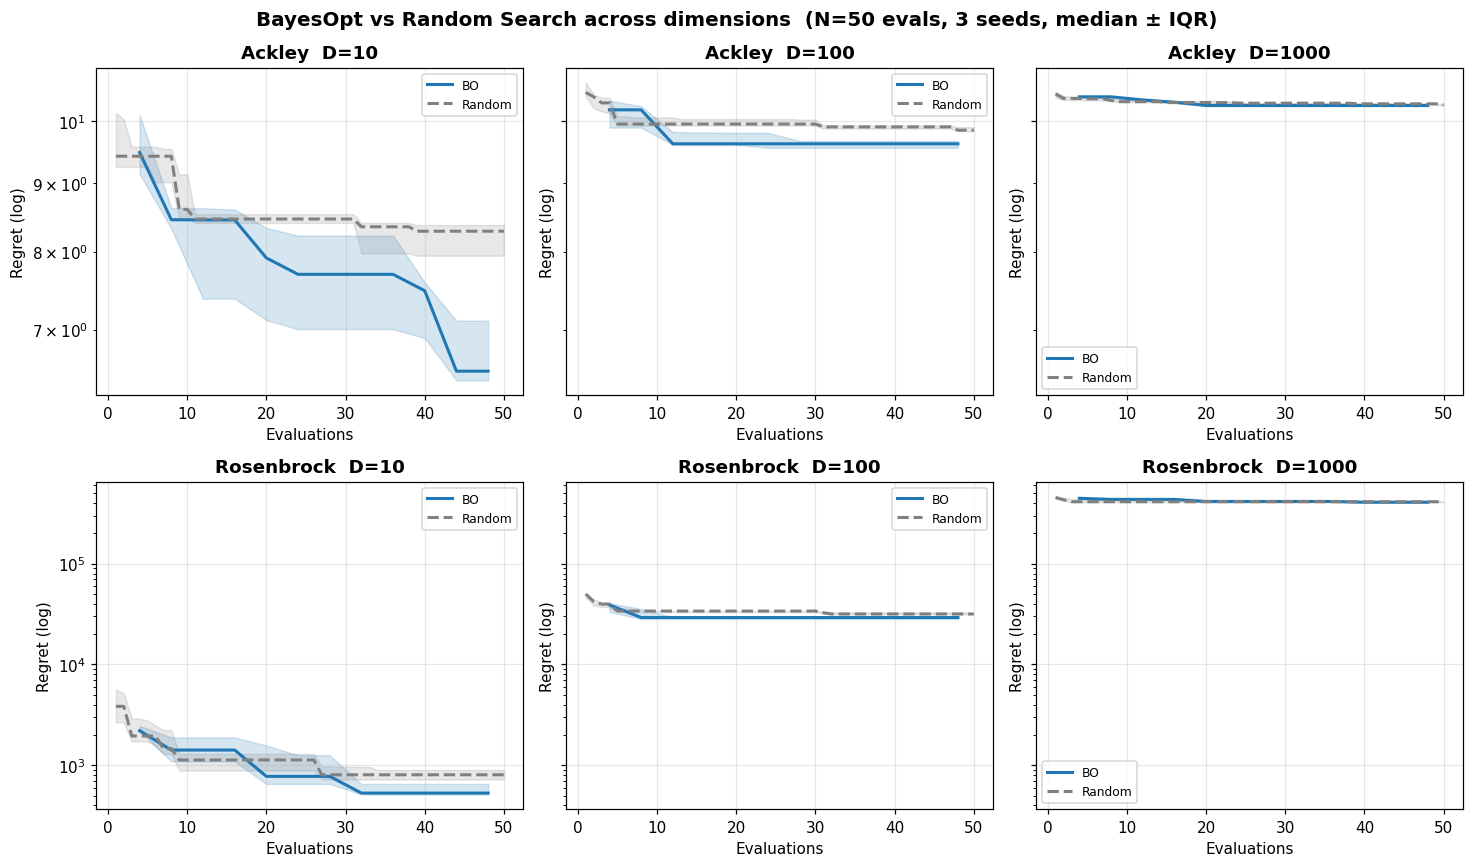

In [5]:
fig, axes = plt.subplots(len(FUNCTIONS), len(DIMS),
                         figsize=(4.5 * len(DIMS), 4 * len(FUNCTIONS)),
                         sharey="row")

for row, fname in enumerate(FUNCTIONS):
    for col, D in enumerate(DIMS):
        ax = axes[row, col]
        plot_regret(ax, results[(fname, D)], f"{fname}  D={D}")

fig.suptitle(
    f"BayesOpt vs Random Search across dimensions  "
    f"(N={N_BUDGET} evals, {N_SEEDS} seeds, median ± IQR)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()



=== Summary table ===
  Function    D  BO compile (s)  BO run (s)  Random run (s)  BO final regret (median)  Random final regret (median)
    Ackley   10            8.19        0.15           0.001                    6.5180                        8.2841
Rosenbrock   10            7.51        0.09           0.001                  529.1560                      804.1058
    Ackley  100           25.50        0.84           0.009                    9.6219                        9.8488
Rosenbrock  100           23.91        0.39           0.009                29235.1660                    31737.5977
    Ackley 1000          663.25        3.67           0.633                   10.2755                       10.2846
Rosenbrock 1000          570.03        3.05           0.575               407864.8438                   412602.8438


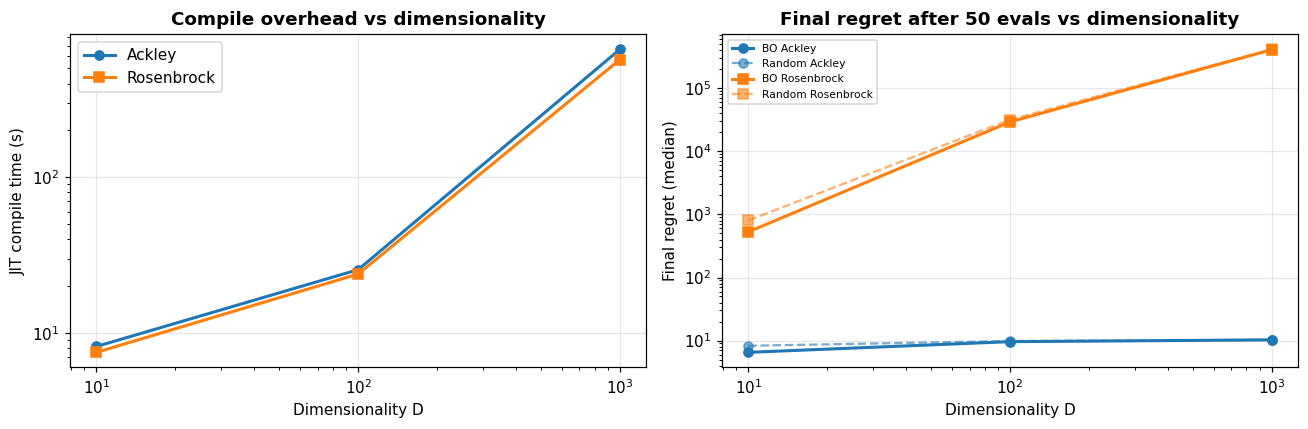

In [6]:
df = pd.DataFrame(timings)
print("\n=== Summary table ===")
print(df.to_string(index=False))

# ── Compile time vs D ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for fname, marker in zip(FUNCTIONS, ["o", "s"]):
    sub = df[df.Function == fname]
    axes[0].plot(sub["D"], sub["BO compile (s)"], marker=marker,
                 label=fname, lw=2)
    axes[1].plot(sub["D"], sub["BO final regret (median)"], marker=marker,
                 label=f"BO {fname}", lw=2)
    axes[1].plot(sub["D"], sub["Random final regret (median)"],
                 marker=marker, linestyle="--",
                 label=f"Random {fname}", lw=1.5, color=axes[1].lines[-1].get_color(),
                 alpha=0.6)

axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Dimensionality D"); axes[0].set_ylabel("JIT compile time (s)")
axes[0].set_title("Compile overhead vs dimensionality", fontweight="bold")
axes[0].legend()

axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("Dimensionality D"); axes[1].set_ylabel("Final regret (median)")
axes[1].set_title(f"Final regret after {N_BUDGET} evals vs dimensionality",
                  fontweight="bold")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()


## Discussion

### What goes wrong at high dimension?

**GP model quality.** With a budget of N evaluations and D dimensions, the ratio
N/D drops from 5 (at D=10) to 0.05 (at D=1000). The GP has only a handful of
observations per dimension — insufficient to learn meaningful length scales or
to interpolate reliably.

**ARD overfitting.** The ARD length scales (one per dimension) are tuned by
maximising the marginal likelihood. With N≪D observations, the optimisation
is severely under-constrained and prone to overfitting — some dimensions get
near-zero length scale (treated as irrelevant) arbitrarily.

**Acquisition maximisation.** `n_candidates=1000` random points cover a
fraction `1000 / 5^D` of the domain — essentially zero for D≥10. The L-BFGS
restarts help somewhat but cannot recover global structure in 1000D with
10 gradient steps.

**Compile time** scales roughly linearly with D due to the size of the ARD
parameter vector and the pytree structure of the search space.

### Rule of thumb

| Regime | Recommendation |
|--------|---------------|
| **D ≤ 20** | Standard GP-BO works well |
| **20 < D ≤ 100** | Increase budget proportionally; consider disabling ARD (`n_hparam_steps=0`) to reduce overfitting |
| **D > 100** | Vanilla GP-BO is not the right tool — consider random search, evolutionary methods, or embedding-based BO (REMBO, ALEBO) |
